In [9]:
%%html
<style> 
/*overwrite hard coded write background by vscode for ipywidges */
.cell-output-ipywidget-background {
   background-color: transparent !important;
}
/*set widget foreground text and color of interactive widget to vs dark theme color */
:root {
    --jp-widgets-color: var(--vscode-editor-foreground);
} 
</style> 

%%html 
<style>
    body {
        --vscode-font-family: "CMU Bright"
    }
</style>


# Render math equations using TeX

You can use TeX to render all of your Matplotlib text by setting
:rc:`text.usetex` to True.  This requires that you have TeX and the other
dependencies described in the `usetex` tutorial properly
installed on your system.  Matplotlib caches processed TeX expressions, so that
only the first occurrence of an expression triggers a TeX compilation. Later
occurrences reuse the rendered image from the cache and are thus faster.

Unicode input is supported, e.g. for the y-axis label in this example.


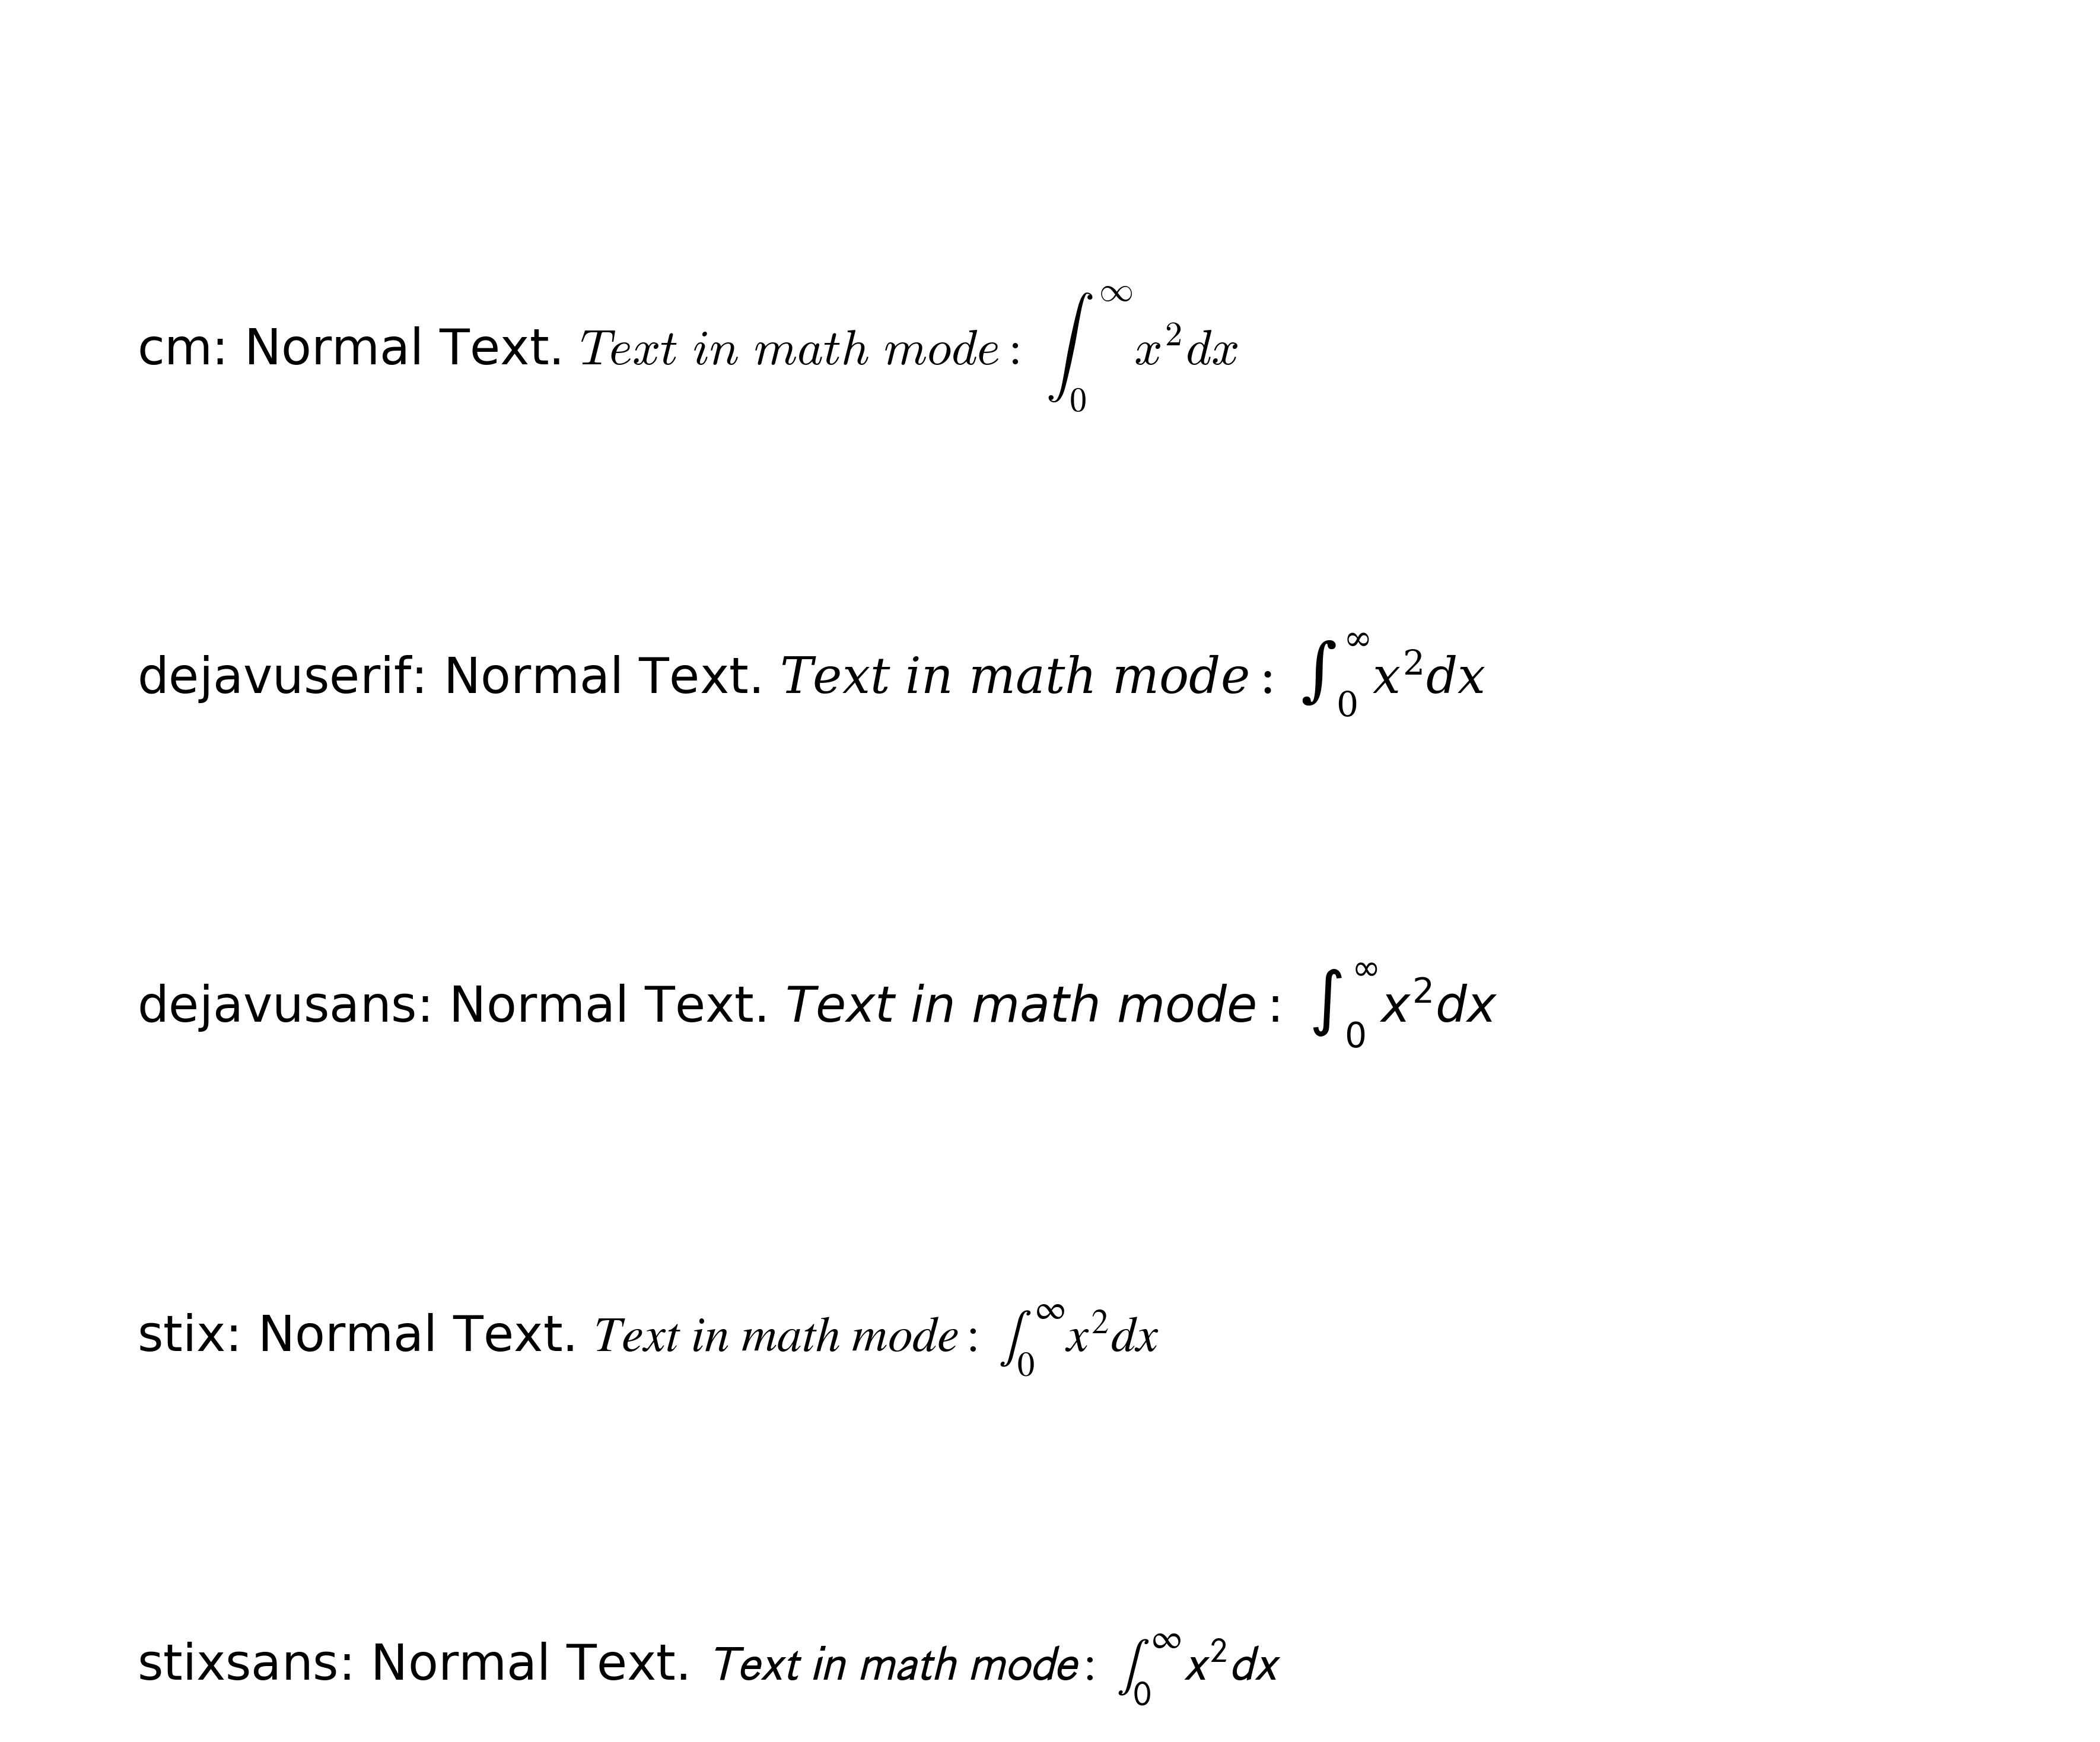

In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

# A text mixing normal text and math text.
msg = (r"Normal Text. $Text\ in\ math\ mode:\ "
       r"\int_{0}^{\infty } x^2 dx$")

# Get all available math font families
math_fonts = ['cm', 'dejavuserif', 'dejavusans', 'stix', 'stixsans']

# Display each math font family within plot area
y_positions = [0.8, 0.6, 0.4, 0.2, 0.0]
for i, font in enumerate(math_fonts):
    ax.text(0.05, y_positions[i], f"{font}: {msg}", size=10, math_fontfamily=font, transform=ax.transAxes)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
 
plt.tight_layout()
plt.show()

# Color palette

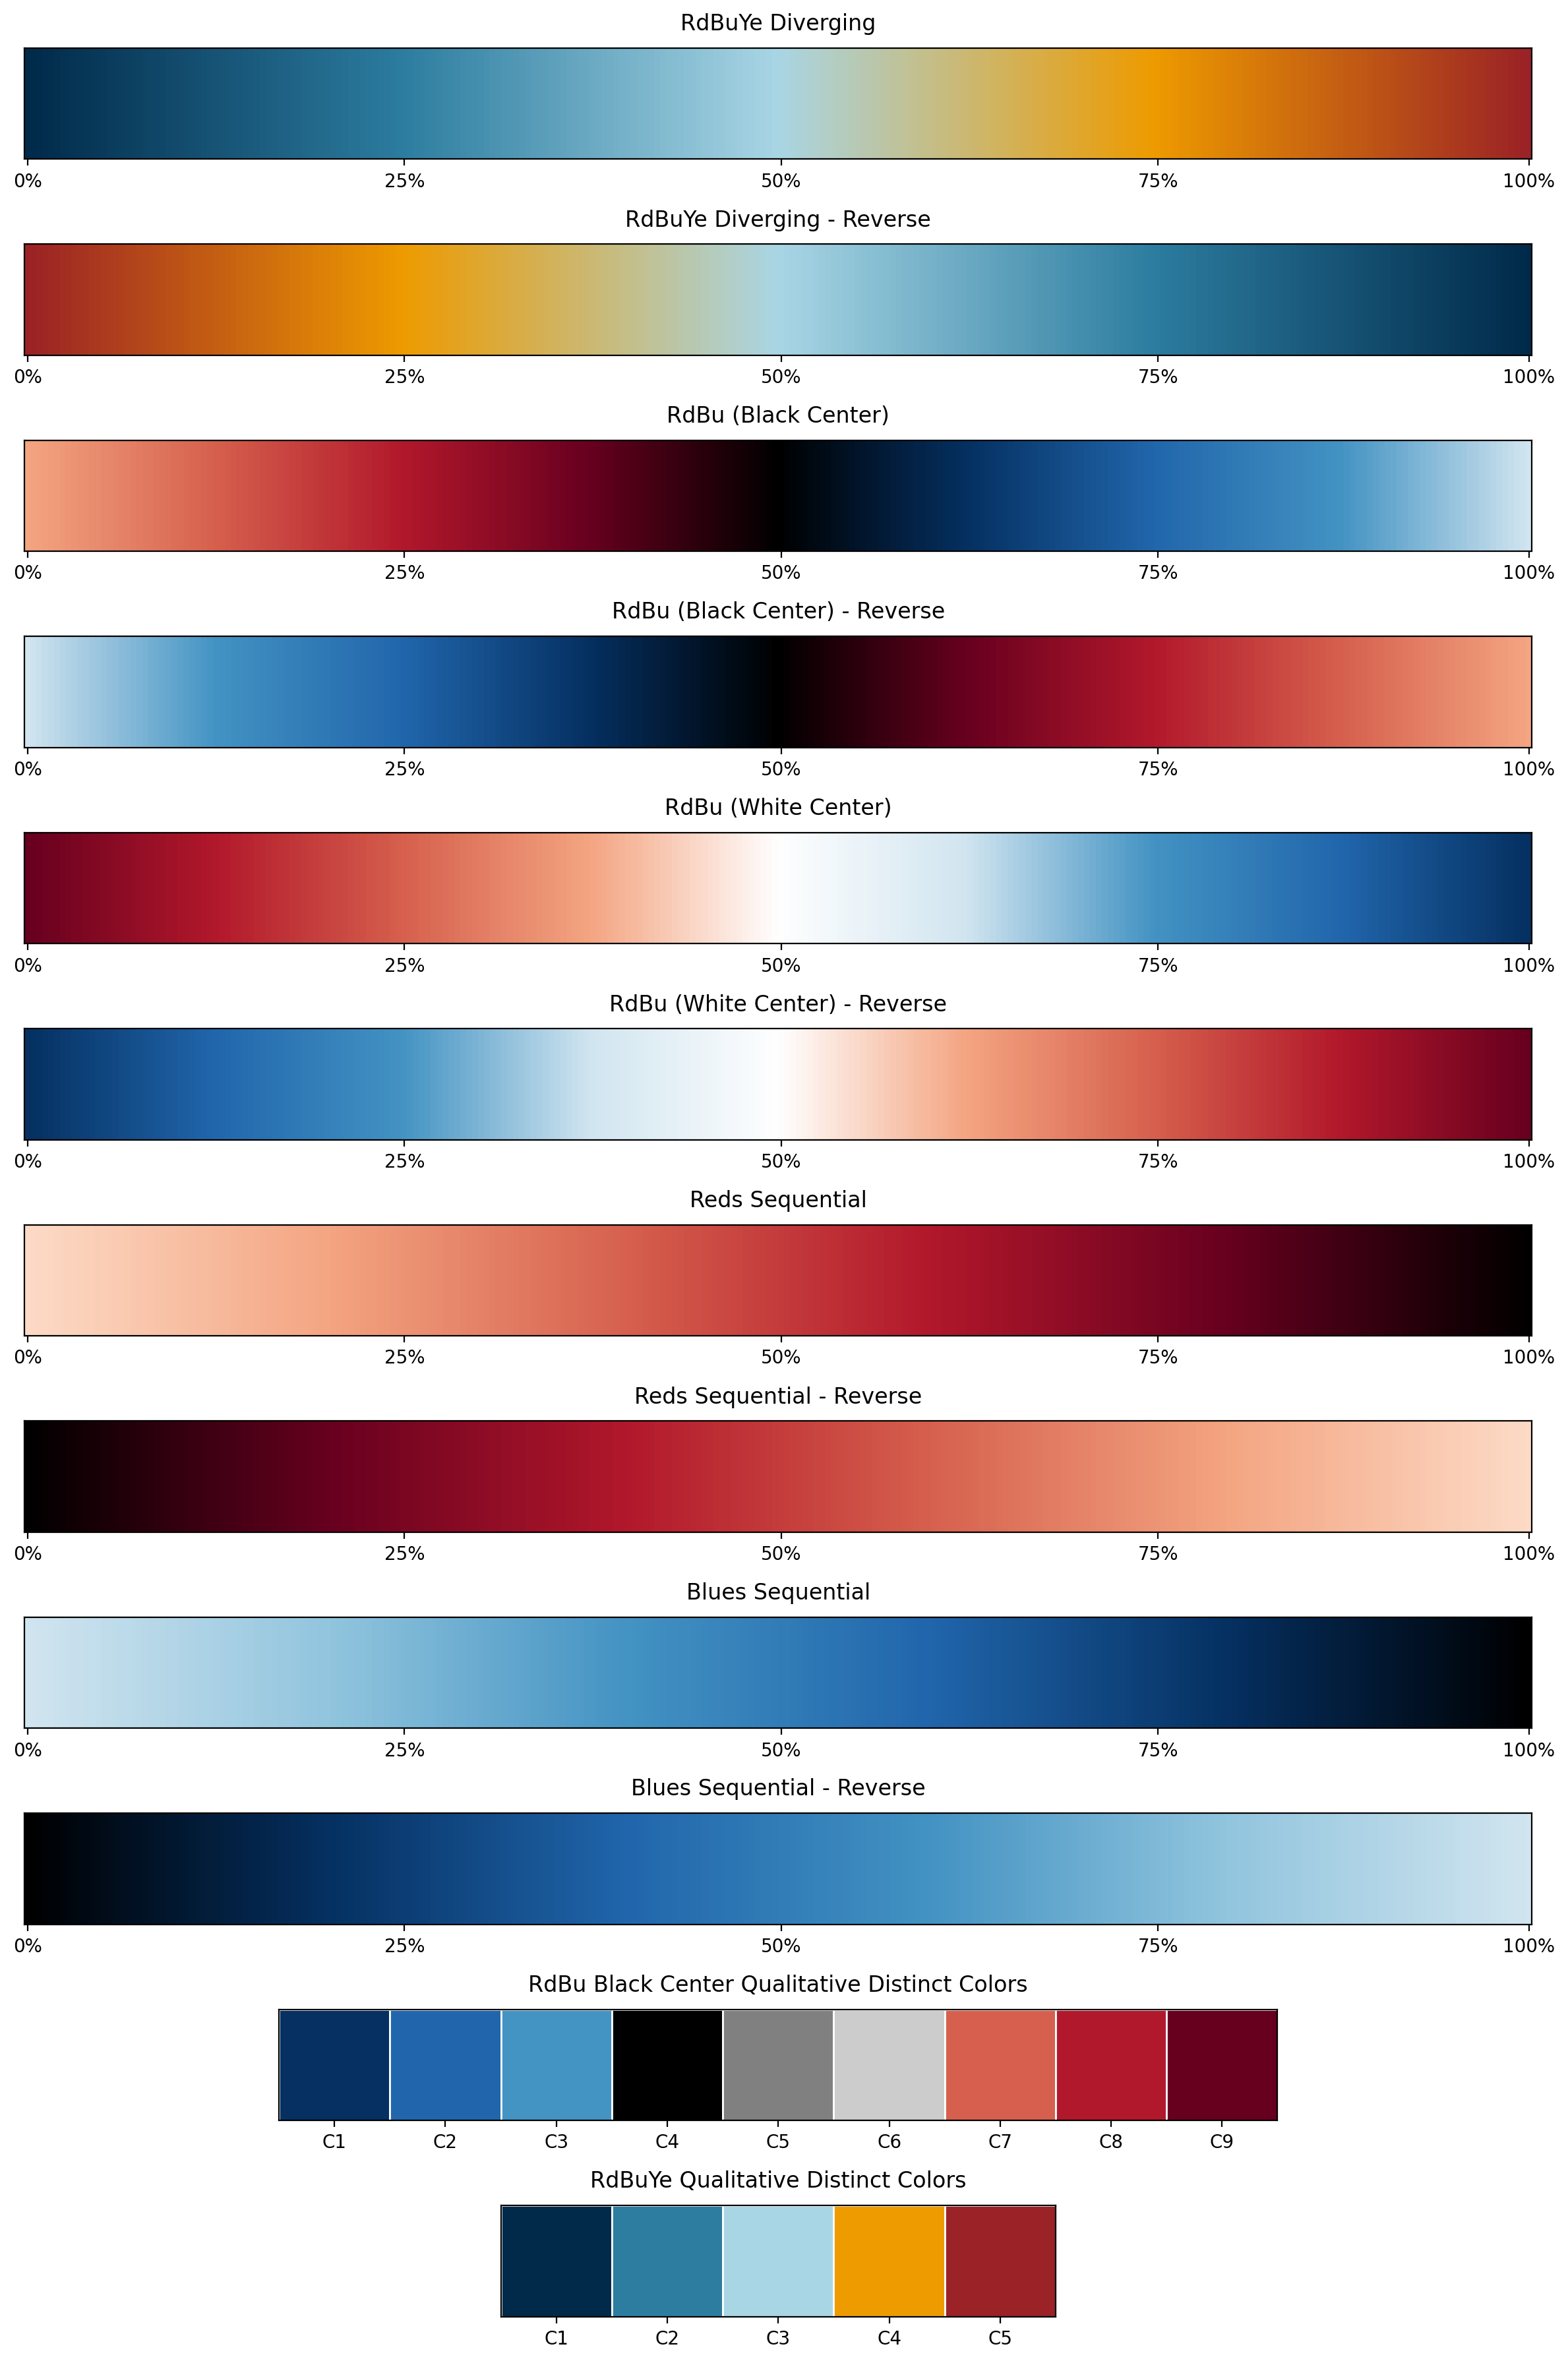

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches

def hex_to_rgb(hex_color):
    """Convert hex color to RGB values."""
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) / 255.0 for i in (0, 2, 4))

def create_color_palette(name, hex_colors):
    """Create a matplotlib colormap from hex colors."""
    rgb_colors = [hex_to_rgb(color) for color in hex_colors]
    return LinearSegmentedColormap.from_list(name, rgb_colors, N=256)

# Define color palettes
RdBuYe = [
    '#012a4a',  # prussian-blue
    '#2c7da0',  # cerulean
    '#a9d6e5',  # light-blue
    '#ee9b00',  # gamboge
    '#9b2226'  # auburn
]

RdBuYe_r = [
    '#9b2226',  # auburn
    '#ee9b00',  # gamboge
    '#a9d6e5',  # light-blue
    '#2c7da0',  # cerulean
    '#012a4a'  # prussian-blue
]

Rdbu_bl = [
    '#f4a582', '#d6604d', '#b2182b', '#67001f', '#000000',
    '#053061', '#2166ac', '#4393c3', '#d1e5f0'
]

Rdbu_bl_r = [
    '#d1e5f0', '#4393c3', '#2166ac', '#053061', '#000000',
    '#67001f', '#b2182b', '#d6604d', '#f4a582'
]

Rdbu_w = [
    '#67001f', '#b2182b', '#d6604d','#f4a582','#ffffff',
    '#d1e5f0', '#4393c3', '#2166ac', '#053061'
]

Rdbu_w_r = [
   '#053061','#2166ac', '#4393c3',  '#d1e5f0',  '#ffffff',
     '#f4a582', '#d6604d', '#b2182b', '#67001f'
]

Rd = [
    '#fddbc7', '#f4a582', '#d6604d', '#b2182b', '#67001f', '#000000'
]

Rd_r = [
    '#000000', '#67001f', '#b2182b', '#d6604d', '#f4a582', '#fddbc7'
]

Bu = [
    '#d1e5f0', '#92c5de', '#4393c3', '#2166ac', '#053061', '#000000'
]

Bu_r = [
    '#000000', '#053061', '#2166ac', '#4393c3', '#92c5de', '#d1e5f0'
]

# Qualitative palettes (distinct colors)
RdBuBl_q = [
    '#053061', '#2166ac', '#4393c3', '#000000', '#808080', 
    '#CCCCCC', '#d6604d', '#b2182b', '#67001f'
]

RdBuYe_q = [
    '#012a4a',  # prussian-blue
    '#2c7da0',  # cerulean
    '#a9d6e5',  # light-blue
    '#ee9b00',  # gamboge
    '#9b2226'  # auburn
]

# Create colormaps for gradients
rdbuye_cmap = create_color_palette('rdbuye', RdBuYe)
rdbuye_r_cmap = create_color_palette('rdbuye_r', RdBuYe_r)
rdbu_bl_cmap = create_color_palette('rdbu_bl', Rdbu_bl)
rdbu_bl_r_cmap = create_color_palette('rdbu_bl_r', Rdbu_bl_r)
rdbu_w_cmap = create_color_palette('rdbu_w', Rdbu_w)
rdbu_w_r_cmap = create_color_palette('rdbu_w_r', Rdbu_w_r)
rd_cmap = create_color_palette('rd', Rd)
rd_r_cmap = create_color_palette('rd_r', Rd_r)
bu_cmap = create_color_palette('bu', Bu)
bu_r_cmap = create_color_palette('bu_r', Bu_r)

def plot_all_palettes():
    """Plot all color palettes - gradients for continuous, swatches for qualitative."""
    
    # Create gradient data
    gradient = np.linspace(0, 1, 256).reshape(1, -1)
    
    # Define gradient palettes (original and reverse)
    gradient_palettes = [
        ('RdBuYe Diverging', rdbuye_cmap),
        ('RdBuYe Diverging - Reverse', rdbuye_r_cmap),
        ('RdBu (Black Center)', rdbu_bl_cmap),
        ('RdBu (Black Center) - Reverse', rdbu_bl_r_cmap),
        ('RdBu (White Center)', rdbu_w_cmap),
        ('RdBu (White Center) - Reverse', rdbu_w_r_cmap),
        ('Reds Sequential', rd_cmap),
        ('Reds Sequential - Reverse', rd_r_cmap),
        ('Blues Sequential', bu_cmap),
        ('Blues Sequential - Reverse', bu_r_cmap)
    ]
    
    # Create figure with 12 rows (10 gradients + 2 qualitative)
    fig, axes = plt.subplots(12, 1, figsize=(12, 18))    
    # Plot gradient palettes
    for idx, (name, cmap) in enumerate(gradient_palettes):
        axes[idx].imshow(gradient, aspect='auto', cmap=cmap)
        axes[idx].set_title(f'{name}', pad=10)
        axes[idx].set_xticks([0, 64, 128, 192, 255])
        axes[idx].set_xticklabels(['0%', '25%', '50%', '75%', '100%'])
        axes[idx].set_yticks([])
    
    # Plot qualitative palette 1 (RdBuBl_q) as distinct swatches
    ax_qual1 = axes[10]
    ax_qual1.set_title('RdBu Black Center Qualitative Distinct Colors', pad=10)
    
    for i, color in enumerate(RdBuBl_q):
        rect = patches.Rectangle((i, 0), 1, 1, 
                               facecolor=color, edgecolor='white', linewidth=1)
        ax_qual1.add_patch(rect)
    
    ax_qual1.set_xlim(0, len(RdBuBl_q))
    ax_qual1.set_ylim(0, 1)
    ax_qual1.set_xticks(np.arange(len(RdBuBl_q)) + 0.5)
    ax_qual1.set_xticklabels([f'C{i+1}' for i in range(len(RdBuBl_q))], rotation=0)
    ax_qual1.set_yticks([])
    ax_qual1.set_aspect('equal')
    
    # Plot qualitative palette 2 (RdBuYe_q) as distinct swatches
    ax_qual2 = axes[11]
    ax_qual2.set_title('RdBuYe Qualitative Distinct Colors', pad=10)
    
    for i, color in enumerate(RdBuYe_q):
        rect = patches.Rectangle((i, 0), 1, 1, 
                               facecolor=color, edgecolor='white', linewidth=1)
        ax_qual2.add_patch(rect)
    
    ax_qual2.set_xlim(0, len(RdBuYe_q))
    ax_qual2.set_ylim(0, 1)
    ax_qual2.set_xticks(np.arange(len(RdBuYe_q)) + 0.5)
    ax_qual2.set_xticklabels([f'C{i+1}' for i in range(len(RdBuYe_q))], rotation=0)
    ax_qual2.set_yticks([])
    ax_qual2.set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

# Run the visualization
plot_all_palettes()

# Minimalist

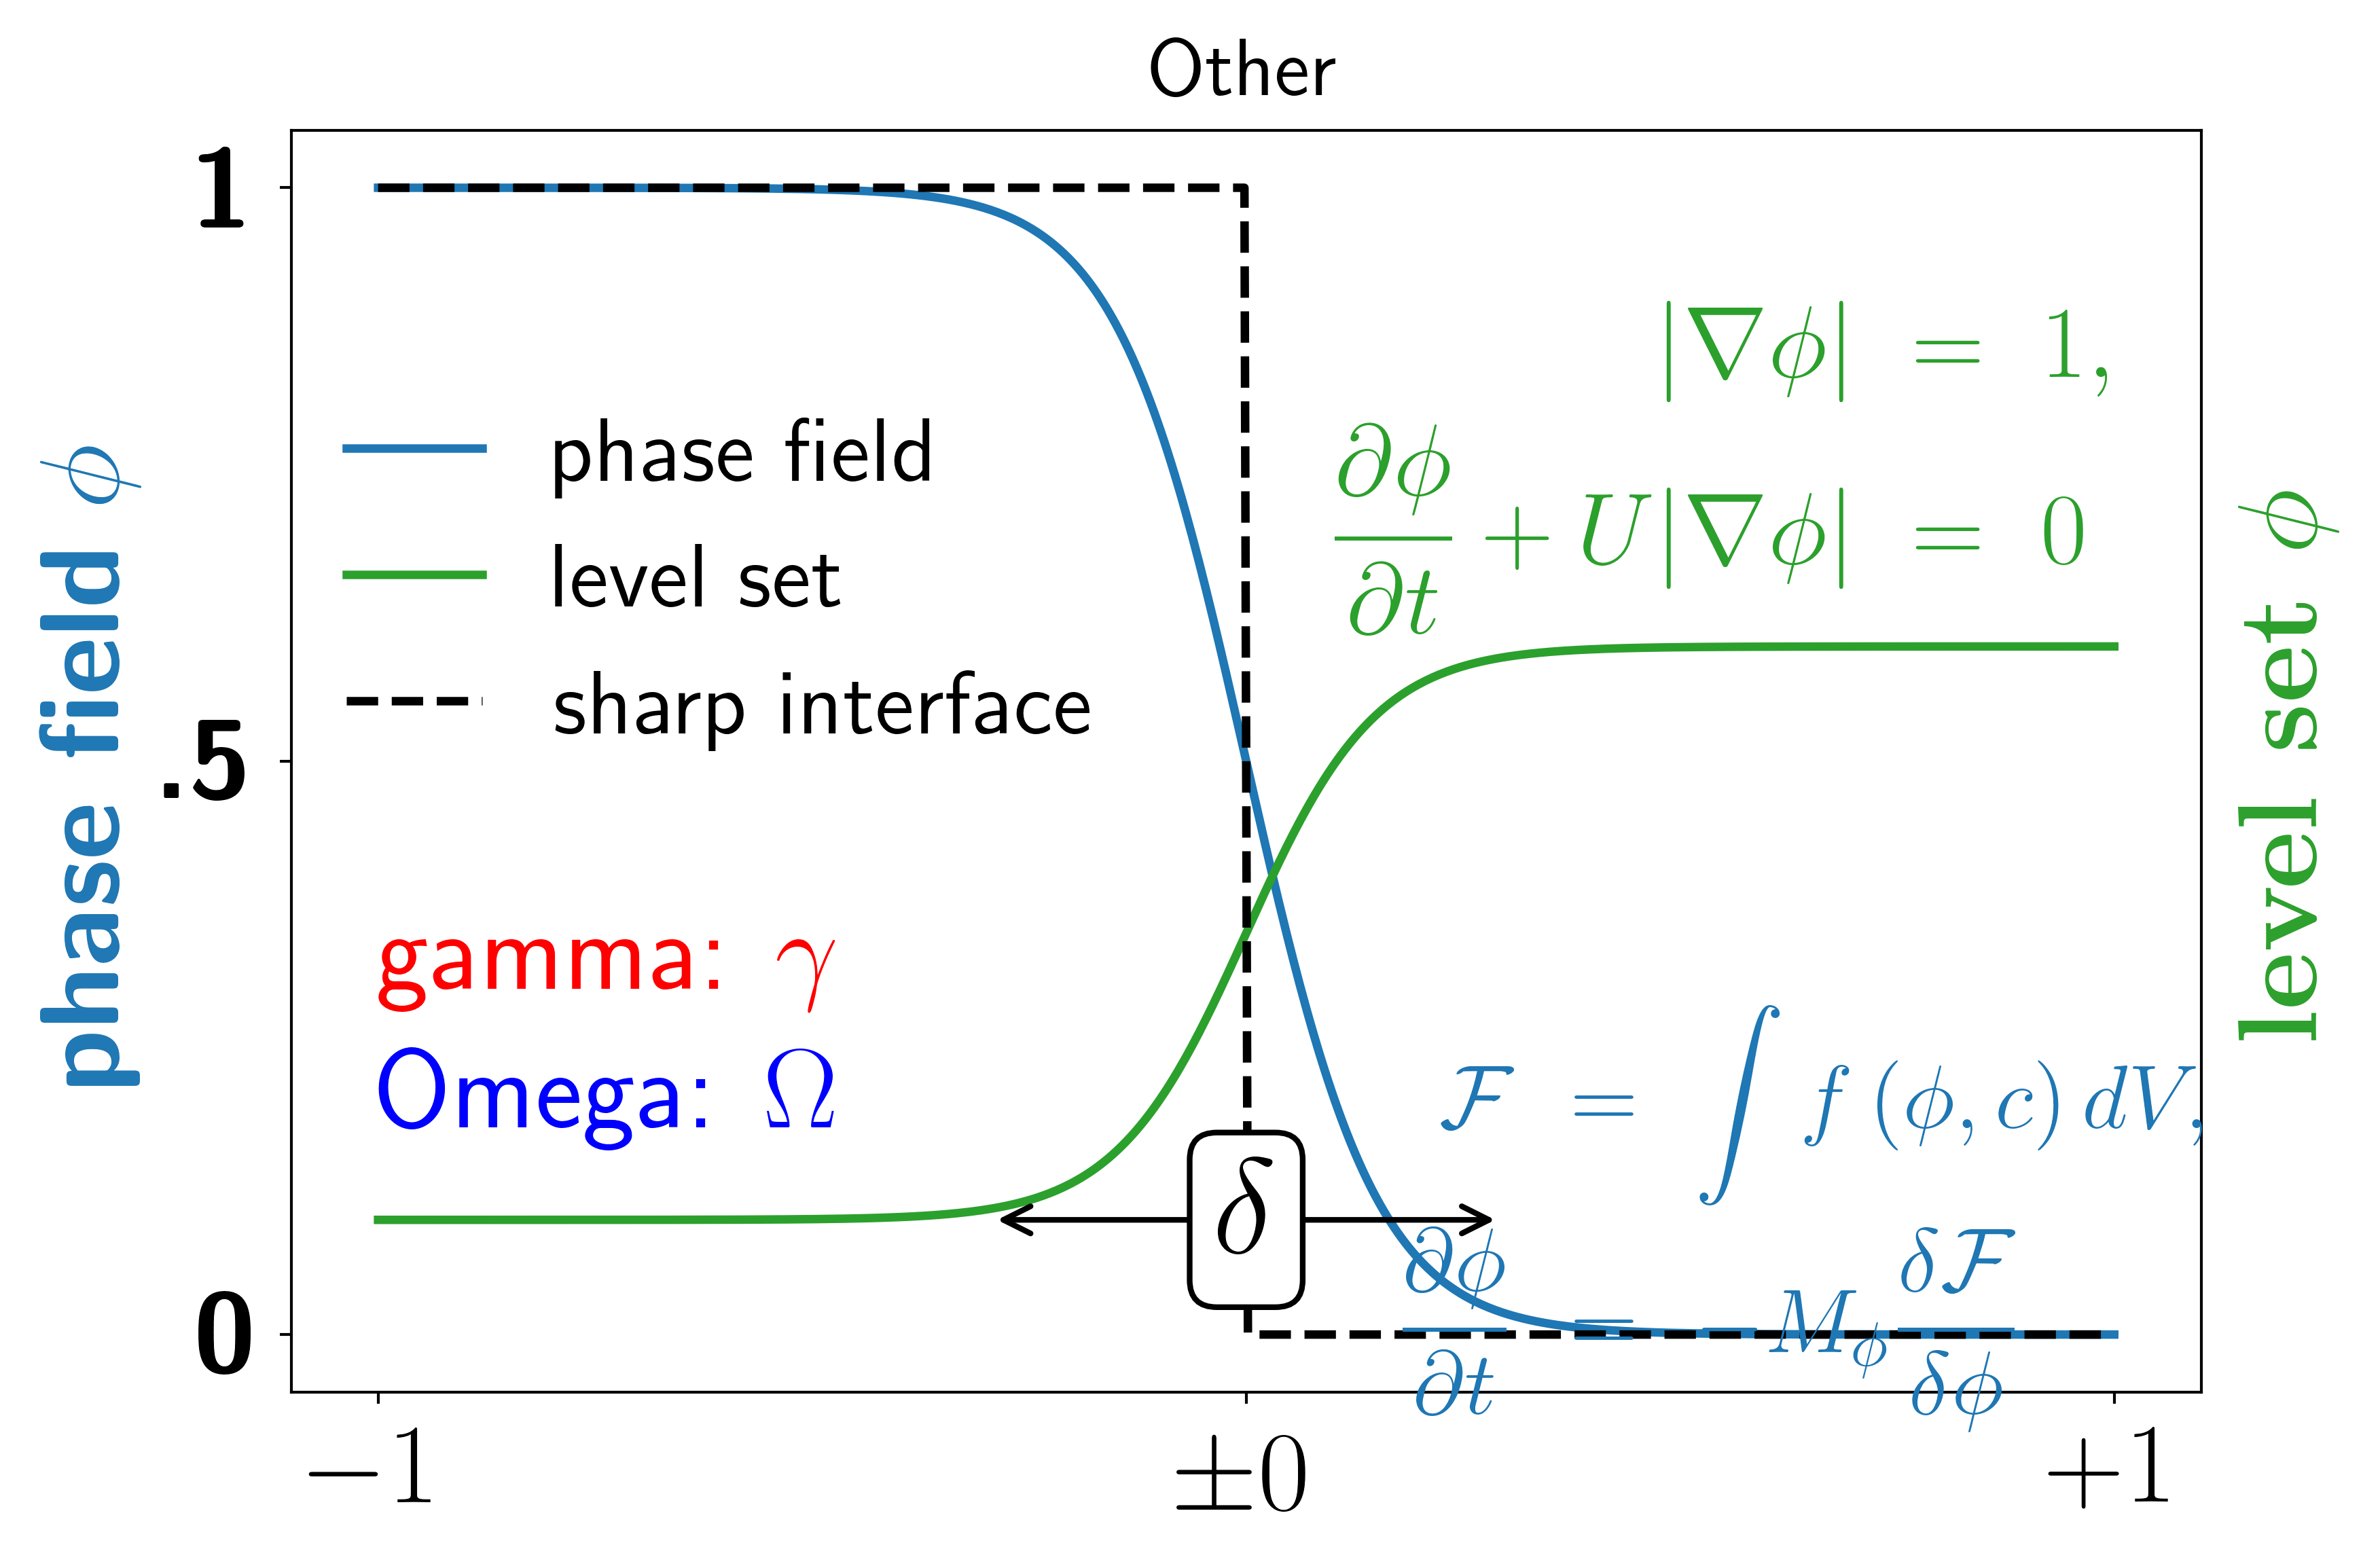

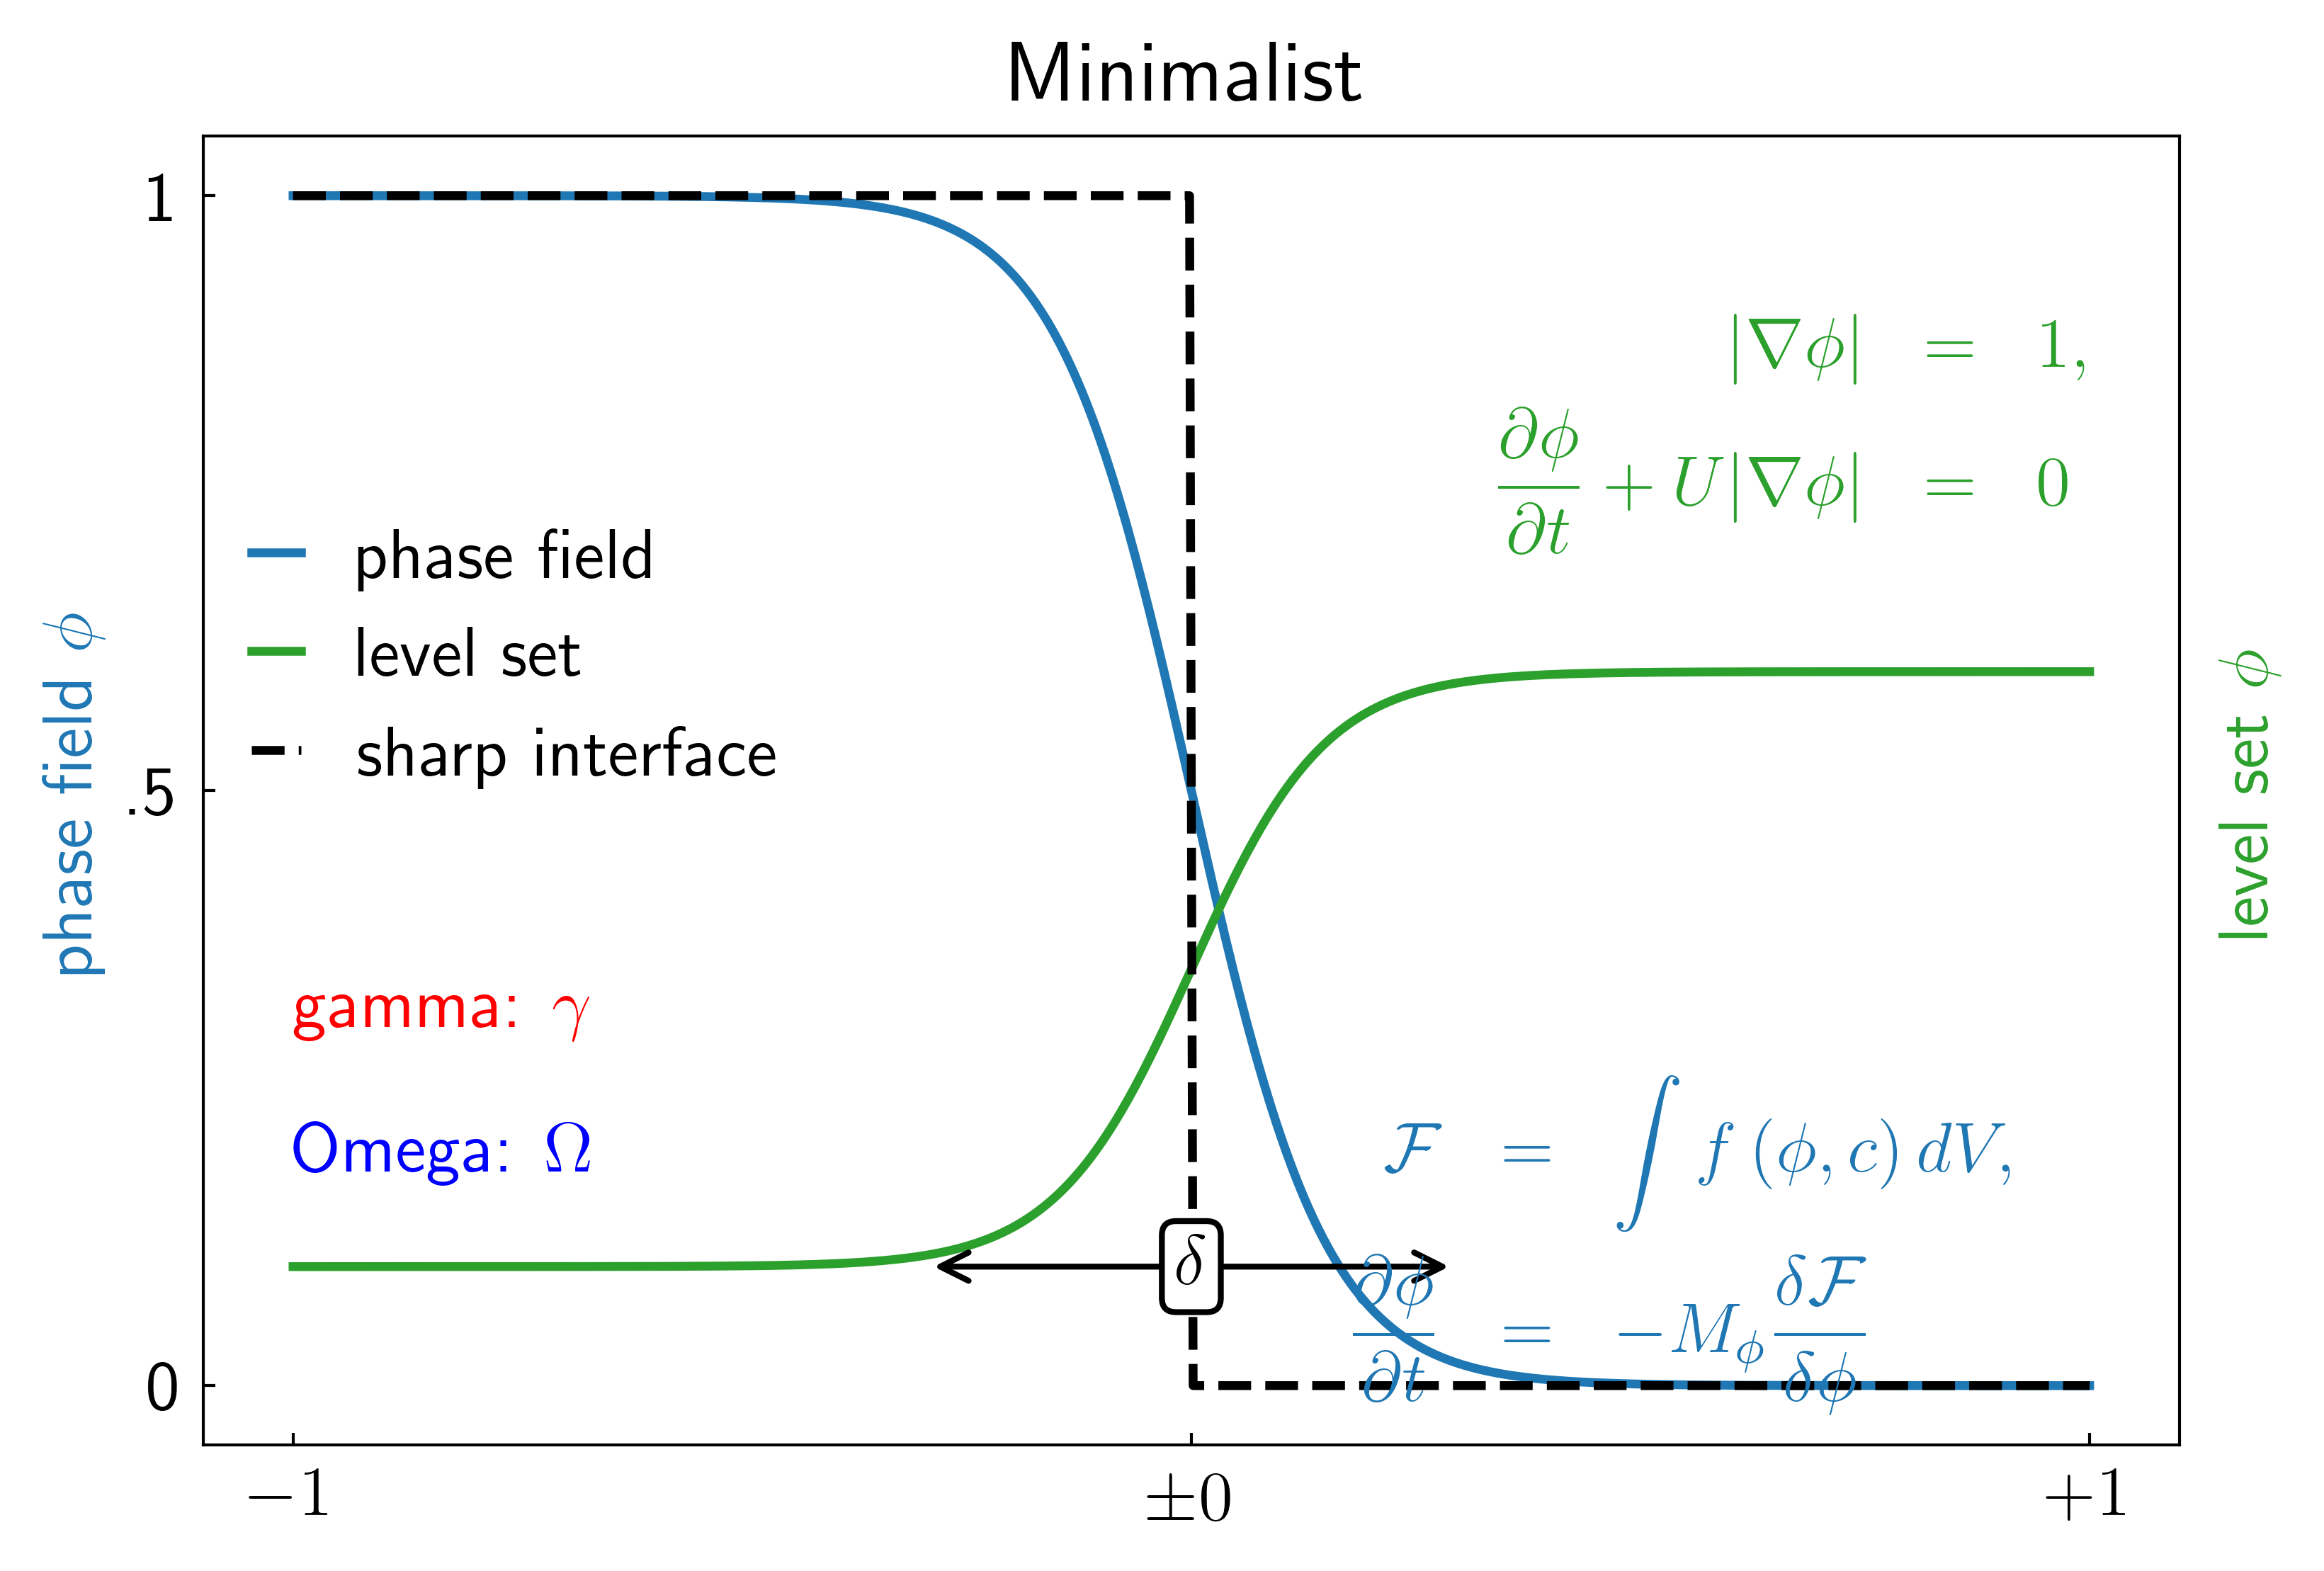

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "text.usetex": True,
    "mathtext.fontset": "cm",
})

fig, ax = plt.subplots(figsize=(6, 4), tight_layout=True, dpi=300)

# interface tracking profiles
N = 500
delta = 0.6
X = np.linspace(-1, 1, N)
ax.plot(X, (1 - np.tanh(4 * X / delta)) / 2,    # phase field tanh profiles
        X, (1.4 + np.tanh(4 * X / delta)) / 4, "C2",  # composition profile
        X, X < 0, "k--")                        # sharp interface

# legend
ax.legend(("phase field", "level set", "sharp interface"),
          shadow=True, loc=(0.01, 0.48), handlelength=1.5, fontsize=16)

# the arrow
ax.annotate("", xy=(-delta / 2., 0.1), xytext=(delta / 2., 0.1),
            arrowprops=dict(arrowstyle="<->", connectionstyle="arc3"))
ax.text(0, 0.1, r"$\delta$",
        color="black", fontsize=24,
        horizontalalignment="center", verticalalignment="center",
        bbox=dict(boxstyle="round", fc="white", ec="black", pad=0.2))

# Use tex in labels
ax.set_xticks([-1, 0, 1])
ax.set_xticklabels(["$-1$", r"$\pm 0$", "$+1$"], color="k", size=20)

# Left Y-axis labels, combine math mode and text mode
ax.set_ylabel(r"\textsf{\textbf{phase field}} $\phi$", color="C0", fontsize=20)
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels([r"\textsf{\textbf{0}}", r"\textsf{\textbf{.5}}", r"\textsf{\textbf{1}}"], color="k", size=20)

# Right Y-axis labels
ax.text(1.02, 0.5, r"\bf{level set} $\phi$",
        color="C2", fontsize=20, rotation=90,
        horizontalalignment="left", verticalalignment="center",
        clip_on=False, transform=ax.transAxes)

# Use multiline environment inside a `text`.
# level set equations
eq1 = (r"\begin{eqnarray*}"
       r"|\nabla\phi| &=& 1,\\"
       r"\frac{\partial \phi}{\partial t} + U|\nabla \phi| &=& 0 "
       r"\end{eqnarray*}")
ax.text(1, 0.9, eq1, color="C2", fontsize=18,
        horizontalalignment="right", verticalalignment="top")

# phase field equations
eq2 = (r"\begin{eqnarray*}"
       r"\mathcal{F} &=& \int f\left( \phi, c \right) dV, \\ "
       r"\frac{ \partial \phi } { \partial t } &=& -M_{ \phi } "
       r"\frac{ \delta \mathcal{F} } { \delta \phi }"
       r"\end{eqnarray*}")
ax.text(0.18, 0.18, eq2, color="C0", fontsize=16)
ax.text(-1, .30, r"gamma: $\gamma$", color="r", fontsize=20)
ax.text(-1, .18, r"Omega: $\Omega$", color="b", fontsize=20)
plt.title("Other")
plt.show()


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "text.usetex": True,
    "legend.frameon": False,
    "legend.handlelength": 0.7,
    "legend.fontsize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 0.5,
    "axes.edgecolor": "black",
    "axes.facecolor": "None",
    "xtick.major.width": 0.5,
    "xtick.minor.width": 0.5,
    "ytick.major.width": 0.5,
    "ytick.minor.width": 0.5,
    "xtick.major.size": 2,
    "xtick.minor.size": 2,
    "ytick.major.size": 2,
    "ytick.minor.size": 2,
})

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

# interface tracking profiles
N = 500
delta = 0.6
X = np.linspace(-1, 1, N)
ax.plot(X, (1 - np.tanh(4 * X / delta)) / 2,    # phase field tanh profiles
        X, (1.4 + np.tanh(4 * X / delta)) / 4, "C2",  # composition profile
        X, X < 0, "k--")                        # sharp interface

# legend
ax.legend(("phase field", "level set", "sharp interface"),
          shadow=False, loc=(0.01, 0.48), handlelength=0.7, frameon=False)

# the arrow
ax.annotate("", xy=(-delta / 2., 0.1), xytext=(delta / 2., 0.1),
            arrowprops=dict(arrowstyle="<->", connectionstyle="arc3"))
ax.text(0, 0.1, r"$\delta$",
        color="black",
        horizontalalignment="center", verticalalignment="center",
        bbox=dict(boxstyle="round", fc="white", ec="black", pad=0.2))

# Use tex in labels
ax.set_xticks([-1, 0, 1])
ax.set_xticklabels(["$-1$", r"$\pm 0$", "$+1$"], color="k")
ax.tick_params(axis='x', which='major', direction='in')

# Left Y-axis labels, combine math mode and text mode
ax.set_ylabel(r"phase field $\phi$", color="C0")
ax.set_yticks([0, 0.5, 1])
ax.set_yticklabels([r"0", r".5", r"1"], color="k")
ax.tick_params(axis='y', which='major', direction='in')

# Right Y-axis labels
ax.text(1.02, 0.5, r"level set $\phi$",
        color="C2", rotation=90,
        horizontalalignment="left", verticalalignment="center",
        clip_on=False, transform=ax.transAxes)

# Use multiline environment inside a `text`.
# level set equations
eq1 = (r"\begin{eqnarray*}"
       r"|\nabla\phi| &=& 1,\\"
       r"\frac{\partial \phi}{\partial t} + U|\nabla \phi| &=& 0 "
       r"\end{eqnarray*}")
ax.text(1, 0.9, eq1, color="C2",
        horizontalalignment="right", verticalalignment="top")

# phase field equations
eq2 = (r"\begin{eqnarray*}"
       r"\mathcal{F} &=& \int f\left( \phi, c \right) dV, \\ "
       r"\frac{ \partial \phi } { \partial t } &=& -M_{ \phi } "
       r"\frac{ \delta \mathcal{F} } { \delta \phi }"
       r"\end{eqnarray*}")
       
ax.text(0.18, 0.18, eq2, color="C0")
ax.text(-1, .30, r"gamma: $\gamma$", color="r")
ax.text(-1, .18, r"Omega: $\Omega$", color="b")
plt.title("Minimalist")
plt.show()